<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/shared/03_paint_damage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Boya ve Hasar Özellik Mühendisliği (Takım 3)

## Giriş ve Strateji
Bu not defterinde, araçların boya ve kaporta durumlarını belirten serbest metin (free-text) sütunlarını işleyeceğiz.
Veri setini incelediğimizde iki büyük zorlukla karşılaştık:
1. `Boya-değişen` sütunu parça ismi vermeden sadece adet belirtiyor (Örn: "2 değişen, 1 boyalı").
2. Diğer sütunlar (`Boyalı`, `Değişmiş` vb.) parça isimlerini veriyor ancak eksik girişler (kullanıcı hataları) barındırıyor.

**Çözüm Yaklaşımımız:**
Çift sayımı (Double Counting) önlemek ve en doğru hasar skorunu elde etmek için:
- `Boya-değişen` sütunundaki sayıları **Düzenli İfadeler (Regex)** ile çekeceğiz.
- Diğer sütunlardaki gerçek parça isimlerini (13 temel parça) kelime bazlı eşleştirme ile sayacağız.
- İki kaynaktan gelen verileri karşılaştırıp **maksimum (max)** olanı alarak çakışmaları önleyeceğiz.
- Ek olarak (Bonus), modelin hasarın ciddiyetini anlayabilmesi için her bir parçanın durumunu (0: Sağlam, 1: Lokal/Belirtilmemiş, 2: Boyalı, 3: Değişmiş) gösteren **Sıralı Kodlama (Ordinal Encoding)** matrisi oluşturacağız.

In [42]:
import pandas as pd
import numpy as np
import re

# 1. Veri setini GitHub üzerinden yükle
RAW_URL = "https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/raw_dataset.csv"
df_full = pd.read_csv(RAW_URL)

# Takım 3'e atanan sütunları seç ve eksik değerleri '-' ile doldur
MY_COLUMNS = ['Boya-değişen', 'Orjinal', 'Lokal boyalı', 'Boyalı', 'Değişmiş', 'Belirtilmemiş']
df = df_full[MY_COLUMNS].copy().fillna('-')

print(f"Veri seti başarıyla yüklendi. Boyut: {df.shape}")
display(df.head(10))

Veri seti başarıyla yüklendi. Boyut: (3424, 6)


,Boya-değişen,Orjinal,Lokal boyalı,Boyalı,Değişmiş,Belirtilmemiş
0,Tamamı orjinal,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,-,-,-
1,Belirtilmemiş,-,-,-,-,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...
2,Tamamı orjinal,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,-,-,-
3,3 boyalı,-,-,Sağ Arka Çamurluk Sol Arka Çamurluk Sağ Ön Çam...,-,Arka Kaput Sağ Arka Kapı Sağ Ön Kapı Tavan Sol...
4,1 değişen,Sağ Arka Çamurluk Sol Arka Çamurluk Sağ Arka K...,-,-,Arka Kaput,-
5,1 lokal boyalı,Sağ Arka Çamurluk Sol Arka Çamurluk Sağ Arka K...,Arka Kaput,-,-,-
6,2 boyalı,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,Ön Tampon Arka Tampon,-,-
7,1 lokal boyalı,-,Sol Arka Çamurluk,-,-,Sağ Arka Çamurluk Arka Kaput Sağ Arka Kapı Sağ...
8,Tamamı orjinal,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,-,-,-
9,2 lokal boyalı,Arka Kaput Sol Arka Çamurluk Sağ Ön Kapı Tavan...,Sağ Arka Çamurluk Sağ Arka Kapı,-,-,-


## Adım 1: Regex ile Sayısal Veri Çıkarımı
`Boya-değişen` sütunundaki metinlerden değişen, boyalı ve lokal boyalı parça sayılarını Düzenli İfadeler (Regex) kullanarak güvenli bir şekilde çektik.

In [43]:
def extract_regex_counts(text):
    # Sonuçları tutacak sözlük (başlangıçta hepsi 0)
    counts = {'reg_degisen': 0, 'reg_boyali': 0, 'reg_lokal': 0}

    # Metni küçük harfe çevir (büyük/küçük harf sorununu önlemek için)
    text_lower = str(text).lower()

    # Özel durumlar (anlamsız veya boş veriler)
    if text in ['-', 'Belirtilmemiş', 'Tamamı orjinal', '']:
        return pd.Series(counts)

    # Tüm parçalar boyalıysa
    if 'tamamı boyalı' in text_lower:
        counts['reg_boyali'] = 13
        return pd.Series(counts)

    # Tüm parçalar lokal boyalıysa
    if 'tamamı lokal boyalı' in text_lower:
        counts['reg_lokal'] = 13
        return pd.Series(counts)

    # findall kullanarak TÜM eşleşmeleri yakala
    deg_list = re.findall(r'(\d+)\s*(değişen|degisen)', text_lower)
    lok_list = re.findall(r'(\d+)\s*lokal', text_lower)
    boy_list = re.findall(r'(\d+)\s*(boyalı|boyali)', text_lower)

    # Bulunan tüm değerleri topla
    counts['reg_degisen'] = sum(int(x[0]) for x in deg_list)
    counts['reg_lokal'] = sum(int(x) for x in lok_list)
    counts['reg_boyali'] = sum(int(x[0]) for x in boy_list)

    # Sonucu pandas Series olarak döndür
    return pd.Series(counts)

# Fonksiyonu uygula ve geçici sütunlar olarak ekle
regex_df = df['Boya-değişen'].apply(extract_regex_counts)
df = pd.concat([df, regex_df], axis=1)

display(regex_df.head(10))

,reg_degisen,reg_boyali,reg_lokal
0,0,0,0
1,0,0,0
2,0,0,0
3,0,3,0
4,1,0,0
5,0,0,1
6,0,2,0
7,0,0,1
8,0,0,0
9,0,0,2


## Adım 2: Akıllı Parça Sayımı ve Çift Sayımı Önleme (Double-Counting Prevention)
Türkiye pazarındaki 13 temel kaporta parçasını tanımladık. Hem Regex sonuçlarını hem de doğrudan parça isimlerini saydık. Bazen satıcılar hem özet sayıyı (Boya-değişen) hem de parça isimlerini girer. Bu çakışmayı önlemek için her iki kaynaktan gelen sayının **en büyüğünü (np.maximum)** alarak gerçek hasar sayılarını (`total_painted_parts`, `total_changed_parts`) hesapladık.

In [44]:
# 13 Temel Kaporta Parçası
CAR_PARTS = [
    'sağ arka çamurluk', 'sol arka çamurluk', 'sağ ön çamurluk', 'sol ön çamurluk',
    'sağ arka kapı', 'sol arka kapı', 'sağ ön kapı', 'sol ön kapı',
    'arka kaput', 'motor kaputu', 'ön tampon', 'arka tampon', 'tavan'
]

def count_keywords(text):
    if text in ['-', '', '0', 'tamamı orjinal', 'belirtilmemiş']:
        return 0
    text_lower = str(text).lower()
    # Kelimeler arasındaki boşlukları değil, listedeki spesifik parçaları sayıyoruz
    return sum(1 for part in CAR_PARTS if part in text_lower)

# Parça isimlerini sütunlardan say
kw_boyali = df['Boyalı'].apply(count_keywords)
kw_lokal = df['Lokal boyalı'].apply(count_keywords)
kw_degisen = df['Değişmiş'].apply(count_keywords)

# İSTENEN TEMEL SÜTUNLAR (Çift sayımı önleyerek)
# Boyalı parçalar (Normal + Lokal)
df['total_painted_parts'] = np.maximum(df['reg_boyali'], kw_boyali) + np.maximum(df['reg_lokal'], kw_lokal)

# Değişen parçalar
df['total_changed_parts'] = np.maximum(df['reg_degisen'], kw_degisen)

# Orjinal mi?
df['is_fully_original'] = (df['Boya-değişen'].str.strip().str.lower() == 'tamamı orjinal').astype(int)

# Boya-değişen sütununda bahsedilen toplam parça
df['Boya-değişen_count'] = df['reg_degisen'] + df['reg_boyali'] + df['reg_lokal']

# Genel hasar skoru (Tüm boyalı ve değişenlerin toplamı)
df['paint_damage_score'] = df['total_painted_parts'] + df['total_changed_parts']

display(df.head(10))

,Boya-değişen,Orjinal,Lokal boyalı,Boyalı,Değişmiş,Belirtilmemiş,reg_degisen,reg_boyali,reg_lokal,total_painted_parts,total_changed_parts,is_fully_original,Boya-değişen_count,paint_damage_score
0,Tamamı orjinal,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,-,-,-,0,0,0,0,0,1,0,0
1,Belirtilmemiş,-,-,-,-,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,0,0,0,0,0,0,0,0
2,Tamamı orjinal,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,-,-,-,0,0,0,0,0,1,0,0
3,3 boyalı,-,-,Sağ Arka Çamurluk Sol Arka Çamurluk Sağ Ön Çam...,-,Arka Kaput Sağ Arka Kapı Sağ Ön Kapı Tavan Sol...,0,3,0,3,0,0,3,3
4,1 değişen,Sağ Arka Çamurluk Sol Arka Çamurluk Sağ Arka K...,-,-,Arka Kaput,-,1,0,0,0,1,0,1,1
5,1 lokal boyalı,Sağ Arka Çamurluk Sol Arka Çamurluk Sağ Arka K...,Arka Kaput,-,-,-,0,0,1,1,0,0,1,1
6,2 boyalı,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,Ön Tampon Arka Tampon,-,-,0,2,0,2,0,0,2,2
7,1 lokal boyalı,-,Sol Arka Çamurluk,-,-,Sağ Arka Çamurluk Arka Kaput Sağ Arka Kapı Sağ...,0,0,1,1,0,0,1,1
8,Tamamı orjinal,Sağ Arka Çamurluk Arka Kaput Sol Arka Çamurluk...,-,-,-,-,0,0,0,0,0,1,0,0
9,2 lokal boyalı,Arka Kaput Sol Arka Çamurluk Sağ Ön Kapı Tavan...,Sağ Arka Çamurluk Sağ Arka Kapı,-,-,-,0,0,2,2,0,0,2,2


## Adım 3: Sıralı Kodlama (Ordinal Encoding) Matrisi - BONUS ÖZELLİK
Modelin hasarın **türünü ve ciddiyetini** (örn: tavan hasarı fiyatı daha çok düşürür) anlayabilmesi için, 13 parçanın her biri için özel bir sütun oluşturduk.
Hasar Puanlaması (Ordinal):
* `0` = Orjinal / Sağlam
* `1` = Lokal Boyalı veya Belirtilmemiş (Hafif Hasar / Risk)
* `2` = Boyalı (Orta Hasar)
* `3` = Değişmiş (Ağır Hasar)

In [46]:
def get_part_status(row, part):
    # En ağır hasardan en hafife doğru kontrol ediyoruz
    if part in str(row['Değişmiş']).lower():
        return 3
    elif part in str(row['Boyalı']).lower():
        return 2
    elif part in str(row['Lokal boyalı']).lower() or part in str(row['Belirtilmemiş']).lower():
        return 1
    else:
        return 0

# Her parça için durum sütunu oluştur
status_cols = []
for part in CAR_PARTS:
    col_name = f"{part.replace(' ', '_')}_durumu"
    status_cols.append(col_name)
    df[col_name] = df.apply(lambda row: get_part_status(row, part), axis=1)

# Orijinal metin sütunlarını at, sadece üretilen sayısal özellikleri sakla
FINAL_COLUMNS = [
    'total_painted_parts', 'total_changed_parts', 'is_fully_original',
    'Boya-değişen_count', 'paint_damage_score'
] + status_cols

df_team3 = df[FINAL_COLUMNS].copy()

# Doğrulama Testleri
assert df_team3.isnull().sum().sum() == 0, "Hata: Null değerler var!"
assert df_team3.select_dtypes(exclude=[np.number]).shape[1] == 0, "Hata: Sayısal olmayan sütun var!"

print(" Takım 3 için özellik mühendisliği (Feature Engineering) başarıyla tamamlandı.")
print(f"Final Veri Seti Boyutu: {df_team3.shape}")
display(df_team3.head(20))

 Takım 3 için özellik mühendisliği (Feature Engineering) başarıyla tamamlandı.
Final Veri Seti Boyutu: (3424, 18)


,total_painted_parts,total_changed_parts,is_fully_original,Boya-değişen_count,paint_damage_score,sağ_arka_çamurluk_durumu,sol_arka_çamurluk_durumu,sağ_ön_çamurluk_durumu,sol_ön_çamurluk_durumu,sağ_arka_kapı_durumu,sol_arka_kapı_durumu,sağ_ön_kapı_durumu,sol_ön_kapı_durumu,arka_kaput_durumu,motor_kaputu_durumu,ön_tampon_durumu,arka_tampon_durumu,tavan_durumu
0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,3,0,0,3,3,2,2,2,1,1,1,1,1,1,1,1,1,1
4,0,1,0,1,1,0,0,0,0,0,0,0,0,3,0,0,0,0
5,1,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0
6,2,0,0,2,2,0,0,0,0,0,0,0,0,0,0,2,2,0
7,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
8,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,2,0,0,2,2,1,0,0,0,1,0,0,0,0,0,0,0,0


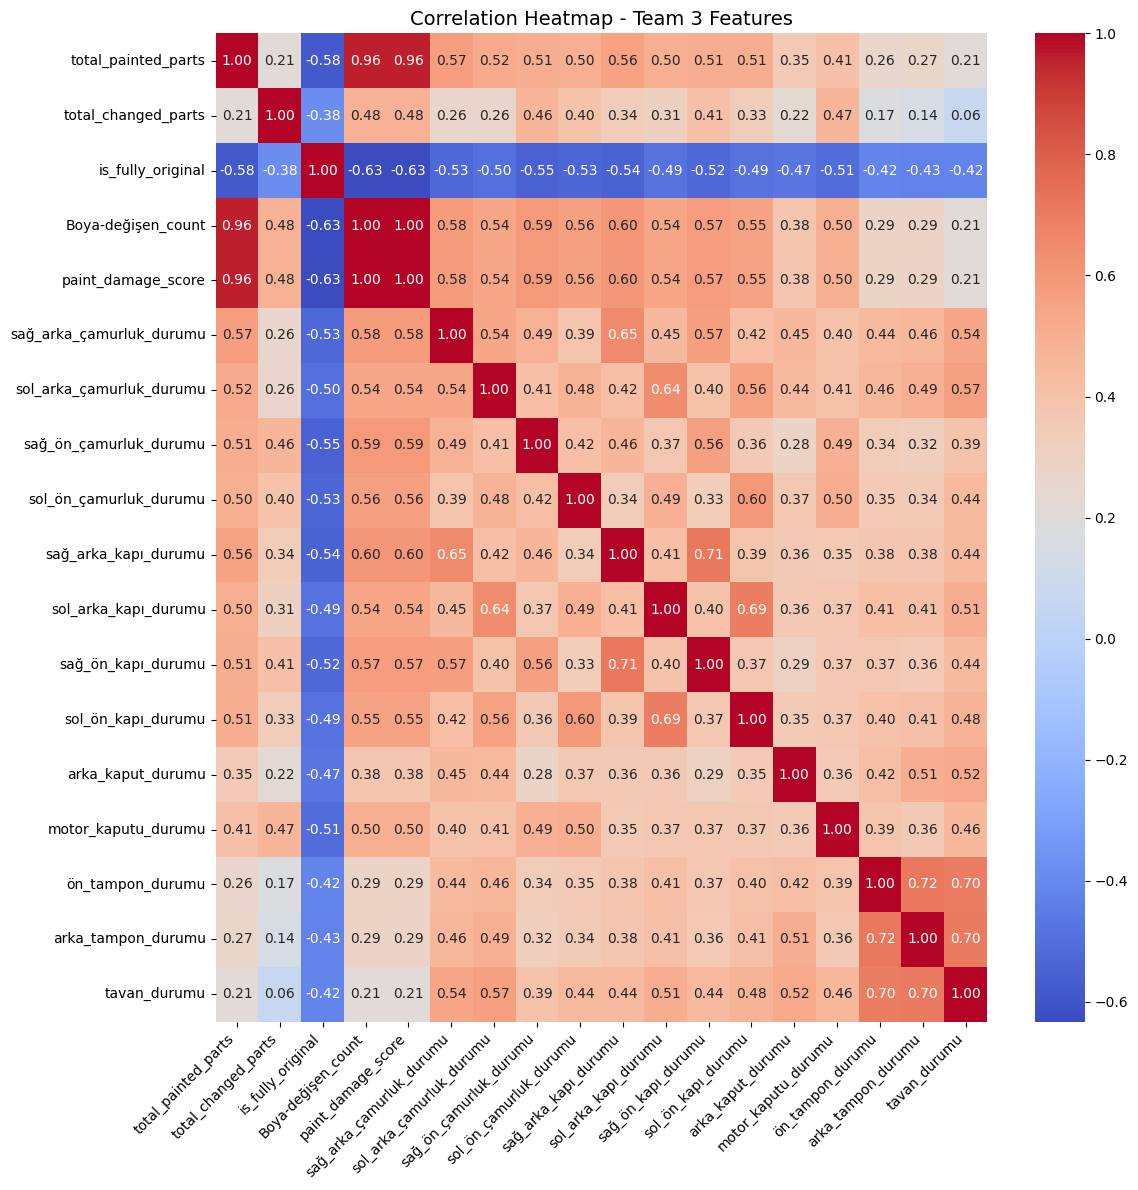

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,12))
sns.heatmap(df_team3.corr(),
            annot=True,
            cmap='coolwarm',      # nice color scheme
            fmt='.2f')

plt.title('Correlation Heatmap - Team 3 Features', fontsize=14)
plt.xticks(rotation=45, ha='right')   # rotate x labels if needed
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()